Assumptions used for CO2 anchor:
- Room: `50 x 30 x 15 ft`
- Outdoor CO2: `420 ppm`
- ACH reference: `4`
- CO2 generation per person: `0.018 m^3/h/person`


In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
ROOT = Path.cwd()

# Load sensor files
s1_raw = pd.read_csv(ROOT / 'data' / '354.csv')
s2_raw = pd.read_csv(ROOT / 'data' / '354_2.csv')

# Parse timestamps
s1_raw['time'] = pd.to_datetime(s1_raw['time'], errors='coerce')
s2_raw['time'] = pd.to_datetime(s2_raw['time'], errors='coerce')

# Numeric conversion
for col in ['CO2_value', 'VOC_value', 'Zone Temp_value']:
    if col in s1_raw.columns:
        s1_raw[col] = pd.to_numeric(s1_raw[col], errors='coerce')

for col in ['Zone CO2_value', 'Zone Air Humid_value', 'Zone Temp_value']:
    if col in s2_raw.columns:
        s2_raw[col] = pd.to_numeric(s2_raw[col], errors='coerce')

# Resample and merge
s1 = (
    s1_raw[['time', 'CO2_value', 'VOC_value', 'Zone Temp_value']]
    .set_index('time')
    .sort_index()
    .resample('5min')
    .mean(numeric_only=True)
    .rename(columns={
        'CO2_value': 'co2_s1',
        'VOC_value': 'voc',
        'Zone Temp_value': 'temp_s1'
    })
)

s2 = (
    s2_raw[['time', 'Zone CO2_value', 'Zone Air Humid_value', 'Zone Temp_value']]
    .set_index('time')
    .sort_index()
    .resample('5min')
    .mean(numeric_only=True)
    .rename(columns={
        'Zone CO2_value': 'co2_s2',
        'Zone Air Humid_value': 'humidity',
        'Zone Temp_value': 'temp_s2'
    })
)

merged = s1.join(s2, how='outer')
merged['co2'] = merged[['co2_s1', 'co2_s2']].mean(axis=1)
merged['temperature'] = merged[['temp_s1', 'temp_s2']].mean(axis=1)

merged = merged[['voc', 'co2', 'humidity', 'temperature']].copy()
merged.head()

,voc,co2,humidity,temperature
time,,,,
2026-02-09 00:00:00,40.777778,419.041667,NaN,NaN
2026-02-09 00:05:00,40.750000,419.821429,NaN,NaN
2026-02-09 00:10:00,39.200000,419.014286,NaN,NaN
2026-02-09 00:15:00,39.700000,420.250000,NaN,NaN
2026-02-09 00:20:00,39.125000,420.791667,NaN,NaN


In [6]:
# Occupancy estimate from all four features

def minmax_robust(series: pd.Series, q_low: float = 0.05, q_high: float = 0.95) -> pd.Series:
    x = series.copy()
    lo = x.quantile(q_low)
    hi = x.quantile(q_high)
    if pd.isna(lo) or pd.isna(hi) or hi <= lo:
        return pd.Series(0.0, index=x.index)
    y = (x - lo) / (hi - lo)
    return y.clip(0, 1)

# 1) Physics anchor from CO2 (reference ACH)
L_FT, W_FT, H_FT = 50, 30, 15
V_M3 = L_FT * W_FT * H_FT * 0.0283168
C_OUT = 420.0
ACH_REF = 4.0
G_PERSON = 0.018

Q_M3_H = ACH_REF * V_M3
co2_delta = (merged['co2'] - C_OUT).clip(lower=0)
merged['people_co2_anchor'] = Q_M3_H * (co2_delta * 1e-6) / G_PERSON

# 2) Multi-feature occupancy index from CO2/VOC/Humidity/Temp
co2_n = minmax_robust(merged['co2'])
voc_n = minmax_robust(merged['voc'])
hum_n = minmax_robust(merged['humidity'])
temp_n = minmax_robust(merged['temperature'])

# Weights: CO2 strongest, VOC second, humidity/temp supportive
feature_index = (
    0.45 * co2_n.fillna(0) +
    0.30 * voc_n.fillna(0) +
    0.15 * hum_n.fillna(0) +
    0.10 * temp_n.fillna(0)
)

# Scale feature index onto people scale using CO2 anchor P95
anchor_p95 = merged['people_co2_anchor'].quantile(0.95)
merged['people_feature_scaled'] = feature_index * anchor_p95

# 3) Final estimate (blend)
merged['people_estimated'] = (
    0.70 * merged['people_co2_anchor'].fillna(0) +
    0.30 * merged['people_feature_scaled'].fillna(0)
).rolling(3, min_periods=1).mean()

merged[['people_co2_anchor', 'people_feature_scaled', 'people_estimated']].describe().round(2)

,people_co2_anchor,people_feature_scaled,people_estimated
count,8493.00,8516.00,8516.00
mean,6.90,8.11,7.25
std,10.73,6.64,9.26
min,0.00,0.00,0.00
25%,0.00,3.06,1.28
50%,1.98,6.41,3.15
75%,9.25,11.49,9.75
max,81.16,30.31,63.72


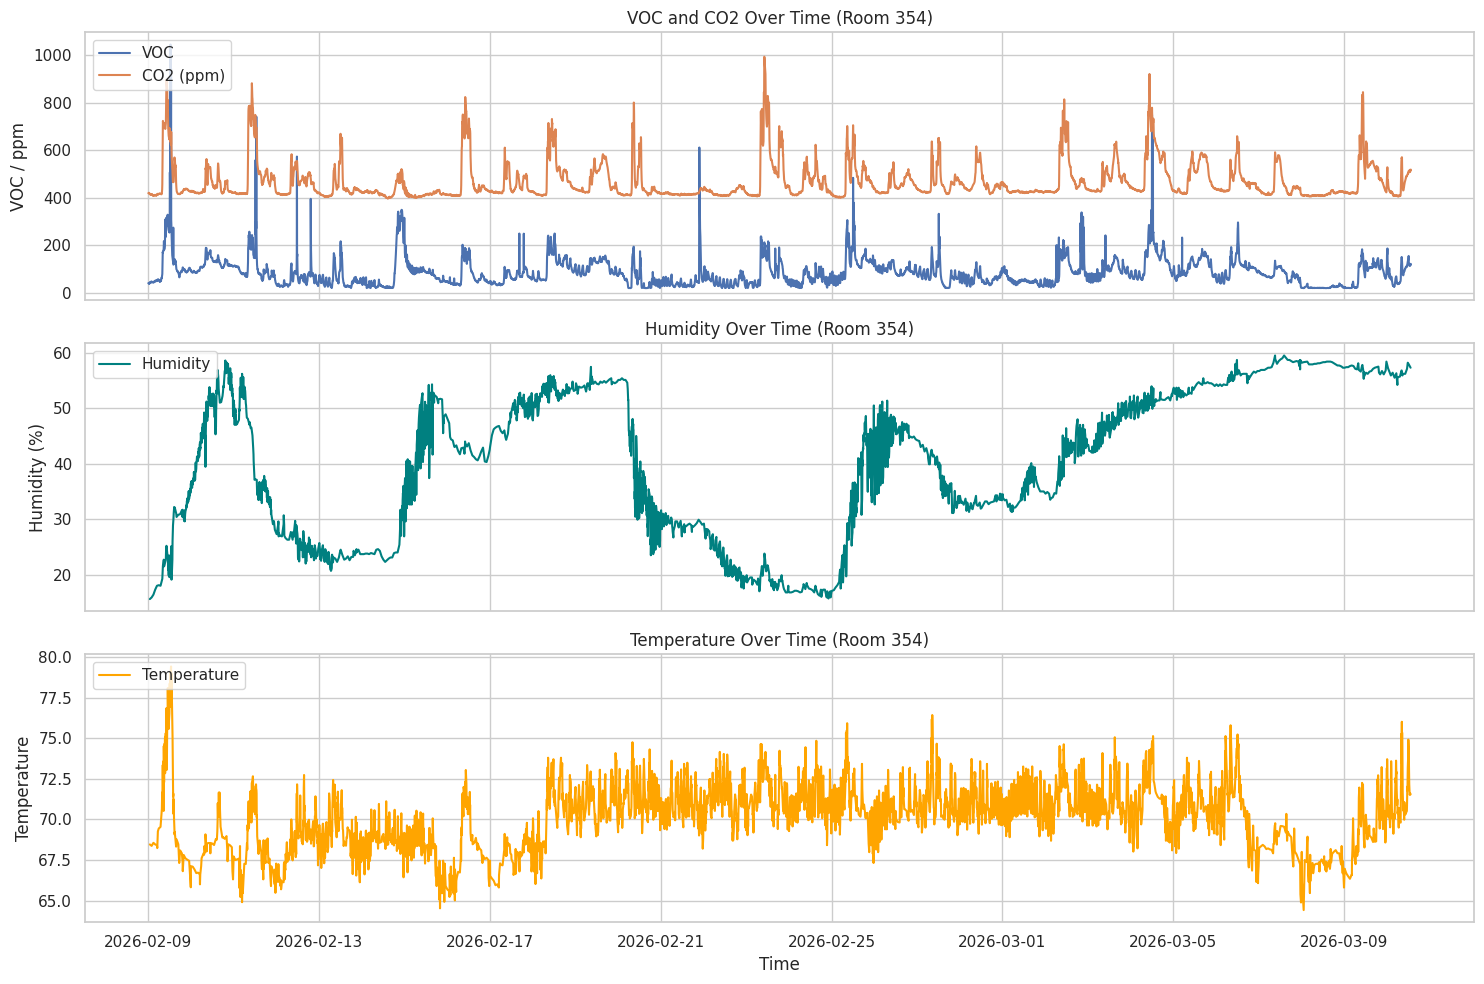

In [7]:
# 3-panel feature comparison
plot_df = merged.copy()

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

# 1) VOC + CO2
sns.lineplot(data=plot_df.reset_index(), x='time', y='voc', ax=axes[0], label='VOC')
sns.lineplot(data=plot_df.reset_index(), x='time', y='co2', ax=axes[0], label='CO2 (ppm)')
axes[0].set_title('VOC and CO2 Over Time (Room 354)')
axes[0].set_ylabel('VOC / ppm')
axes[0].legend(loc='upper left')

# 2) Humidity
sns.lineplot(data=plot_df.reset_index(), x='time', y='humidity', ax=axes[1], color='teal', label='Humidity')
axes[1].set_title('Humidity Over Time (Room 354)')
axes[1].set_ylabel('Humidity (%)')
axes[1].legend(loc='upper left')

# 3) Temperature
sns.lineplot(data=plot_df.reset_index(), x='time', y='temperature', ax=axes[2], color='orange', label='Temperature')
axes[2].set_title('Temperature Over Time (Room 354)')
axes[2].set_ylabel('Temperature')
axes[2].legend(loc='upper left')

axes[2].set_xlabel('Time')

plt.tight_layout()
plt.show()

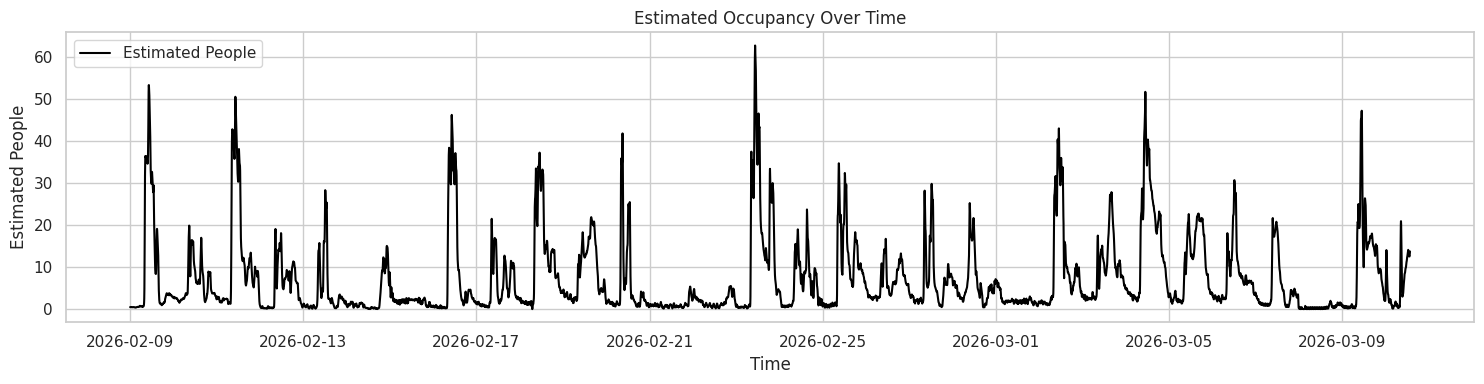

In [8]:
# Estimated occupancy over time
plot_df = merged.copy()

occ_smooth = plot_df['people_estimated'].rolling(3, min_periods=1).mean()

plt.figure(figsize=(15, 4))
sns.lineplot(x=plot_df.index, y=occ_smooth, color='black', label='Estimated People')
plt.title('Estimated Occupancy Over Time')
plt.ylabel('Estimated People')
plt.xlabel('Time')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [9]:
# Optional quick summary
s = merged['people_estimated'].dropna()
print(f'Mean estimate: {s.mean():.1f} people')
print(f'P90 estimate: {s.quantile(0.90):.1f}')
print(f'P95 estimate: {s.quantile(0.95):.1f}')
print(f'P99 estimate: {s.quantile(0.99):.1f}')
print(f'Max estimate: {s.max():.1f}')

Mean estimate: 7.2 people
P90 estimate: 19.8
P95 estimate: 28.4
P99 estimate: 42.1
Max estimate: 63.7
